# 第 1 章：向量基礎

本 Notebook 是 `ch01_vectors.md` 教學文件的精簡互動版，程式碼與 `ch01_vectors.py` 邏輯一致。

## 學習目標

- 理解純量與向量的定義、行向量與列向量的記號
- 熟悉向量加法、純量乘法的計算與幾何意義
- 能計算向量的 L1、L2、L∞ 範數
- 理解內積的定義，並用內積求夾角、判斷正交性
- 能將向量正規化為單位向量，並計算向量投影

In [1]:
%matplotlib inline
import os

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# 設定中文字型，避免圖片中的中文顯示為方框
matplotlib.rcParams["font.sans-serif"] = [
    "PingFang TC", "PingFang SC", "Heiti TC", "Arial Unicode MS", "DejaVu Sans",
]
matplotlib.rcParams["axes.unicode_minus"] = False

OUT_DIR = os.getcwd()
print("圖片輸出資料夾:", OUT_DIR)

圖片輸出資料夾: /Users/rexwang/workspace/linear-algebra-with-matlab-python-tutorial/ch01_vectors


## 1. 純量與向量

- **純量 (scalar)**：只有大小、沒有方向的量，例如溫度、質量，記為一般小寫字母 $s$。
- **向量 (vector)**：同時具有大小與方向的量，記為粗體或加箭頭，例如 $\vec{v}$。

向量常以兩種形式書寫：

$$
\text{行向量 (column vector)} = \begin{bmatrix} 2 \\ 3 \end{bmatrix}, \qquad
\text{列向量 (row vector)} = \begin{bmatrix} 2 & 3 \end{bmatrix}
$$

在 NumPy 中，形狀 `(n, 1)` 對應行向量，形狀 `(n,)` 或 `(1, n)` 常用來表示列向量／一般向量。

In [2]:
scalar = 3.0
print("純量 s =", scalar)

col_vec = np.array([[2], [3]])
print("行向量 v (column vector), shape =", col_vec.shape)
print(col_vec)

row_vec = np.array([2, 3])
print("列向量 v (row vector), shape =", row_vec.shape)
print(row_vec)

純量 s = 3.0
行向量 v (column vector), shape = (2, 1)
[[2]
 [3]]
列向量 v (row vector), shape = (2,)
[2 3]


## 2. 向量加法與純量乘法

向量加法採**分量對分量相加**：

$$
\vec{a} + \vec{b} = \begin{bmatrix} a_1 \\ a_2 \end{bmatrix} + \begin{bmatrix} b_1 \\ b_2 \end{bmatrix} = \begin{bmatrix} a_1+b_1 \\ a_2+b_2 \end{bmatrix}
$$

幾何意義：把 $\vec{b}$ 平移到 $\vec{a}$ 的終點，從原點到新終點的向量就是 $\vec{a}+\vec{b}$（平行四邊形法則）。

純量乘法則是把每個分量都乘上同一個純量 $k$：

$$
k\vec{a} = \begin{bmatrix} k a_1 \\ k a_2 \end{bmatrix}
$$

例如 $a=(2,1),\ b=(1,3)$，則 $a+b=(3,4)$；$2a=(4,2)$。

In [3]:
a = np.array([2, 1])
b = np.array([1, 3])

a_plus_b = a + b
print("向量 a =", a)
print("向量 b =", b)
print("向量 a + b =", a_plus_b)

k = 2
k_times_a = k * a
print(f"純量乘法 {k} * a =", k_times_a)

向量 a = [2 1]
向量 b = [1 3]
向量 a + b = [3 4]
純量乘法 2 * a = [4 2]


## 3. 向量的長度／範數（L1、L2、L∞）

範數是衡量向量「長度」或「大小」的方式，常見有三種：

$$
\|v\|_1 = \sum_i |v_i|, \qquad
\|v\|_2 = \sqrt{\sum_i v_i^2}, \qquad
\|v\|_\infty = \max_i |v_i|
$$

以 $v=(3,-4)$ 為例：$\|v\|_1 = 3+4=7$，$\|v\|_2=\sqrt{9+16}=5$，$\|v\|_\infty=\max(3,4)=4$。

In [4]:
v = np.array([3, -4])
print("向量 v =", v)

l1_norm = np.linalg.norm(v, ord=1)
l2_norm = np.linalg.norm(v, ord=2)
linf_norm = np.linalg.norm(v, ord=np.inf)

print("L1 範數 ||v||_1 =", l1_norm)
print("L2 範數 ||v||_2 =", l2_norm)
print("L∞ 範數 ||v||_inf =", linf_norm)

向量 v = [ 3 -4]
L1 範數 ||v||_1 = 7.0
L2 範數 ||v||_2 = 5.0
L∞ 範數 ||v||_inf = 4.0


## 4. 內積、夾角與正交性

內積（dot product）定義為：

$$
\vec{u} \cdot \vec{w} = \sum_i u_i w_i
$$

內積與夾角的關係：

$$
\cos\theta = \frac{\vec{u}\cdot\vec{w}}{\|\vec{u}\|\,\|\vec{w}\|}
$$

當 $\vec{u}\cdot\vec{w}=0$（且兩者皆非零向量）時，兩向量**正交**（夾角為 $90^\circ$）。

例如 $u=(1,2)$、$w=(3,-1)$：$u\cdot w = 1\times3 + 2\times(-1) = 1$。

In [5]:
u = np.array([1, 2])
w = np.array([3, -1])

dot_uw = np.dot(u, w)
print("向量 u =", u)
print("向量 w =", w)
print("內積 u . w =", dot_uw)

norm_u = np.linalg.norm(u)
norm_w = np.linalg.norm(w)
cos_theta = dot_uw / (norm_u * norm_w)
theta_rad = np.arccos(cos_theta)
theta_deg = np.degrees(theta_rad)

print("|u| =", norm_u)
print("|w| =", norm_w)
print("cos(theta) =", cos_theta)
print("theta (degrees) =", theta_deg)

向量 u = [1 2]
向量 w = [ 3 -1]
內積 u . w = 1
|u| = 2.23606797749979
|w| = 3.1622776601683795
cos(theta) = 0.14142135623730948
theta (degrees) = 81.86989764584402


In [6]:
# 正交性判斷：內積是否為 0
p = np.array([1, 0])
q = np.array([0, 1])
dot_pq = np.dot(p, q)
print("向量 p =", p, "、向量 q =", q)
print("p . q =", dot_pq, "-> p 與 q 正交" if np.isclose(dot_pq, 0) else "-> p 與 q 不正交")

向量 p = [1 0] 、向量 q = [0 1]
p . q = 0 -> p 與 q 正交


## 5. 單位向量（normalize）

單位向量是長度為 1、方向與原向量相同的向量，計算方式是把向量除以自己的範數：

$$
\hat{x} = \frac{\vec{x}}{\|\vec{x}\|}
$$

例如 $x=(3,4)$，$\|x\|=5$，所以 $\hat{x}=(0.6,0.8)$，且 $\|\hat{x}\|=1$。

In [7]:
x = np.array([3, 4])
x_norm = np.linalg.norm(x)
x_unit = x / x_norm

print("向量 x =", x)
print("|x| =", x_norm)
print("單位向量 x_hat = x / |x| =", x_unit)
print("驗證 |x_hat| =", np.linalg.norm(x_unit))

向量 x = [3 4]
|x| = 5.0
單位向量 x_hat = x / |x| = [0.6 0.8]
驗證 |x_hat| = 1.0


## 6. 向量投影（projection of a onto b）

將向量 $\vec{a}$ 投影到向量 $\vec{b}$ 上，得到的向量投影為：

$$
\operatorname{proj}_{\vec{b}}(\vec{a}) = \frac{\vec{a}\cdot\vec{b}}{\vec{b}\cdot\vec{b}}\,\vec{b}
$$

純量投影（即 $\vec{a}$ 在 $\vec{b}$ 方向上的長度）為：

$$
\text{scalar\_proj} = \frac{\vec{a}\cdot\vec{b}}{\|\vec{b}\|}
$$

例如 $a=(3,2)$、$b=(4,0)$：純量投影 $=\dfrac{12}{4}=3$，向量投影 $=(3,0)$。

In [8]:
a2 = np.array([3, 2])
b2 = np.array([4, 0])

scalar_proj = np.dot(a2, b2) / np.linalg.norm(b2)
proj_vec = (np.dot(a2, b2) / np.dot(b2, b2)) * b2

print("向量 a =", a2)
print("向量 b =", b2)
print("純量投影 (scalar projection) =", scalar_proj)
print("向量投影 proj_b(a) =", proj_vec)

向量 a = [3 2]
向量 b = [4 0]
純量投影 (scalar projection) = 3.0
向量投影 proj_b(a) = [3. 0.]


## 7. 幾何圖示：向量加法

下圖以平行四邊形法則展示 $\vec{a}+\vec{b}$：先畫出 $\vec{a}$，再從 $\vec{a}$ 的終點畫出 $\vec{b}$，兩者相接後從原點指向終點即為 $\vec{a}+\vec{b}$。

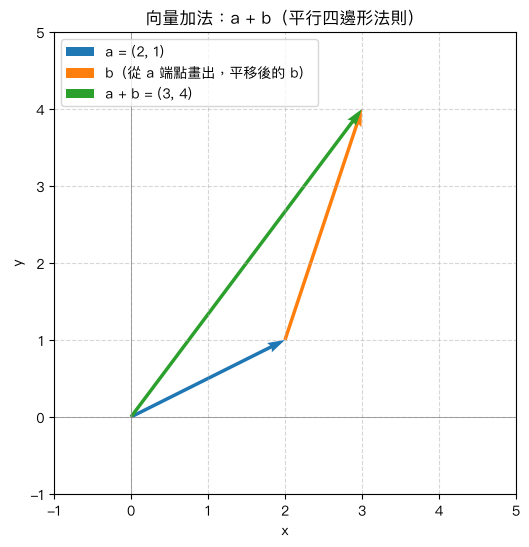

已儲存向量加法示意圖至: /Users/rexwang/workspace/linear-algebra-with-matlab-python-tutorial/ch01_vectors/vector_addition.png


In [9]:
origin = np.array([0, 0])

fig, ax = plt.subplots(figsize=(6, 6))
ax.quiver(*origin, *a, angles="xy", scale_units="xy", scale=1,
          color="tab:blue", label="a = (2, 1)")
ax.quiver(*a, *b, angles="xy", scale_units="xy", scale=1,
          color="tab:orange", label="b（從 a 端點畫出，平移後的 b）")
ax.quiver(*origin, *a_plus_b, angles="xy", scale_units="xy", scale=1,
          color="tab:green", label="a + b = (3, 4)")

ax.set_xlim(-1, 5)
ax.set_ylim(-1, 5)
ax.set_aspect("equal")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_title("向量加法：a + b（平行四邊形法則）")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper left")

fig_path = os.path.join(OUT_DIR, "vector_addition.png")
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print("已儲存向量加法示意圖至:", fig_path)

## 8. 幾何圖示：向量投影

下圖展示 $\vec{a}$ 投影到 $\vec{b}$ 上的結果：綠色向量是投影，灰色虛線是 $\vec{a}$ 垂直於 $\vec{b}$ 的分量。

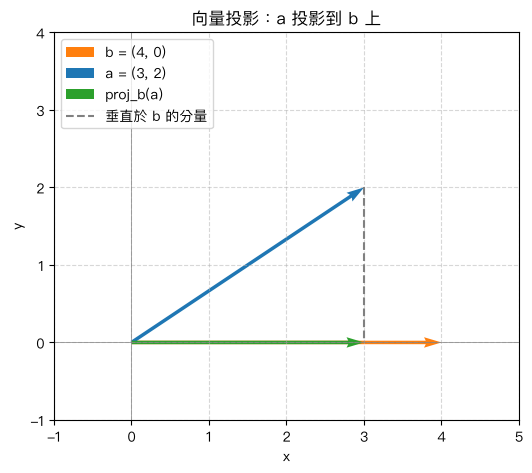

已儲存向量投影示意圖至: /Users/rexwang/workspace/linear-algebra-with-matlab-python-tutorial/ch01_vectors/vector_projection.png


In [10]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.quiver(*origin, *b2, angles="xy", scale_units="xy", scale=1,
          color="tab:orange", label="b = (4, 0)")
ax.quiver(*origin, *a2, angles="xy", scale_units="xy", scale=1,
          color="tab:blue", label="a = (3, 2)")
ax.quiver(*origin, *proj_vec, angles="xy", scale_units="xy", scale=1,
          color="tab:green", label="proj_b(a)")
ax.plot([a2[0], proj_vec[0]], [a2[1], proj_vec[1]],
        linestyle="--", color="gray", label="垂直於 b 的分量")

ax.set_xlim(-1, 5)
ax.set_ylim(-1, 4)
ax.set_aspect("equal")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_title("向量投影：a 投影到 b 上")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper left")

fig_path2 = os.path.join(OUT_DIR, "vector_projection.png")
plt.savefig(fig_path2, dpi=120, bbox_inches="tight")
plt.show()
print("已儲存向量投影示意圖至:", fig_path2)

## 重點整理

- 向量兼具大小與方向，行向量、列向量只是排列方式不同
- 向量加法遵循平行四邊形法則；純量乘法會縮放向量長度（負數則反向）
- L1、L2、L∞ 範數是衡量向量大小的三種常見方式
- 內積可用來計算夾角、判斷正交性（內積為 0 代表垂直）
- 單位向量透過除以自身範數得到，方向不變、長度變為 1
- 向量投影將一個向量分解為平行於另一向量的分量

## 練習題

1. 給定 $a=(1,1)$、$b=(2,-1)$，手算 $a+b$ 與 $3a$。
2. 計算 $v=(6,-8)$ 的 L1、L2、L∞ 範數。
3. 給定 $u=(2,0)$、$w=(0,5)$，判斷是否正交，並說明理由。
4. 求 $x=(1,2,2)$ 的單位向量（3 維向量，範數公式相同）。
5. 給定 $a=(1,3)$、$b=(2,2)$，計算 $\operatorname{proj}_b(a)$，並驗證 $a - \operatorname{proj}_b(a)$ 是否與 $b$ 正交。

可以在下方新增程式碼儲存格，用本章介紹的函式驗證你的手算結果。